In [1]:
import kagglehub
briscdataset_brisc2025_path = kagglehub.dataset_download('briscdataset/brisc2025')

print('Data source import complete.')

!pip install -q albumentations==1.4.3

Data source import complete.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.0/137.0 kB 4.9 MB/s eta 0:00:00


In [2]:
import os, glob, random, warnings, hashlib
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import models

import albumentations as A
from albumentations.pytorch import ToTensorV2

warnings.filterwarnings("ignore")

# ======================
# FLAGS
# ======================
USE_AUGMENTATION = False
USE_CLAHE        = True

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# ✅ SAFE DEVICE SETUP
NUM_GPUS = torch.cuda.device_count()
DEVICE   = torch.device("cuda" if NUM_GPUS > 0 else "cpu")

print("Device:", DEVICE)
print("GPUs:", NUM_GPUS)

Device: cuda
GPUs: 2


In [3]:
DATA_ROOT = "/kaggle/input/datasets/briscdataset/brisc2025/brisc2025"

CLS_TRAIN_DIR = os.path.join(DATA_ROOT, "classification_task", "train")
CLS_TEST_DIR  = os.path.join(DATA_ROOT, "classification_task", "test")

CLASS_NAMES  = ["glioma", "meningioma", "no_tumor", "pituitary"]
CLASS_TO_IDX = {c: i for i, c in enumerate(CLASS_NAMES)}
NUM_CLASSES  = len(CLASS_NAMES)
IMG_SIZE     = 224

In [4]:
def build_cls_df(root_dir):
    rows = []
    for cls_name in CLASS_NAMES:
        cls_dir = os.path.join(root_dir, cls_name)
        if not os.path.isdir(cls_dir):
            continue
        for ext in ("*.jpg", "*.png", "*.jpeg"):
            for fpath in glob.glob(os.path.join(cls_dir, ext)):
                rows.append({
                    "filepath": fpath,
                    "label_name": cls_name,
                    "label": CLASS_TO_IDX[cls_name]
                })
    return pd.DataFrame(rows)

cls_full_df = build_cls_df(CLS_TRAIN_DIR)
cls_test_df = build_cls_df(CLS_TEST_DIR)

print("Initial train:", len(cls_full_df), "| Initial test:", len(cls_test_df))

Initial train: 5000 | Initial test: 1000


In [5]:
def file_hash(path):
    with open(path, 'rb') as f:
        return hashlib.md5(f.read()).hexdigest()

train_hashes = {file_hash(p): p for p in cls_full_df["filepath"]}
duplicates   = [p for p in cls_test_df["filepath"] if file_hash(p) in train_hashes]

print("Duplicates found:", len(duplicates))

cls_test_df = cls_test_df[~cls_test_df["filepath"].isin(duplicates)].reset_index(drop=True)

cls_train_df, cls_val_df = train_test_split(
    cls_full_df, test_size=0.2, stratify=cls_full_df["label"], random_state=SEED
)

print("Train:", len(cls_train_df), "| Val:", len(cls_val_df))

Duplicates found: 7
Train: 4000 | Val: 1000


In [6]:
if USE_AUGMENTATION:
    train_aug = A.Compose([
        A.Resize(IMG_SIZE, IMG_SIZE),
        A.HorizontalFlip(p=0.5),
        A.RandomBrightnessContrast(p=0.3),
        A.Rotate(limit=15, p=0.3),
        A.Normalize(mean=(0.485,0.456,0.406), std=(0.229,0.224,0.225)),
        ToTensorV2(),
    ])
else:
    train_aug = A.Compose([
        A.Resize(IMG_SIZE, IMG_SIZE),
        A.Normalize(mean=(0.485,0.456,0.406), std=(0.229,0.224,0.225)),
        ToTensorV2(),
    ])

test_aug = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.Normalize(mean=(0.485,0.456,0.406), std=(0.229,0.224,0.225)),
    ToTensorV2(),
])

In [7]:
def apply_clahe(img):
    lab = cv2.cvtColor(img, cv2.COLOR_RGB2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(2.0, (8,8))
    l = clahe.apply(l)
    lab = cv2.merge((l,a,b))
    return cv2.cvtColor(lab, cv2.COLOR_LAB2RGB)

class BrainClassDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self): return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = cv2.imread(row["filepath"])
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        if USE_CLAHE:
            img = apply_clahe(img)

        if self.transform:
            img = self.transform(image=img)["image"]

        return img, int(row["label"])

In [8]:
class_counts   = cls_train_df['label'].value_counts().sort_index().values
class_weights  = 1. / torch.tensor(class_counts, dtype=torch.float)
sample_weights = [class_weights[l] for l in cls_train_df['label'].values]

sampler = WeightedRandomSampler(sample_weights, len(sample_weights))

cls_train_ds = BrainClassDataset(cls_train_df, train_aug)
cls_val_ds   = BrainClassDataset(cls_val_df, test_aug)
cls_test_ds  = BrainClassDataset(cls_test_df, test_aug)

cls_train_dl = DataLoader(cls_train_ds, batch_size=32, sampler=sampler, num_workers=2, pin_memory=True)
cls_val_dl   = DataLoader(cls_val_ds, batch_size=32, shuffle=False)
cls_test_dl  = DataLoader(cls_test_ds, batch_size=32
                          
                          
                          , shuffle=False)

In [9]:
def build_efficientnet_b0():
    m = models.efficientnet_b0(weights="IMAGENET1K_V1")
    m.classifier = nn.Sequential(
        nn.Dropout(0.3),
        nn.Linear(m.classifier[1].in_features, NUM_CLASSES)
    )
    return m

In [10]:
def set_efficientnet_grad(
    model,
    freeze_stem=True,
    freeze_stage1=True,
    freeze_stage2=True,
    freeze_stage3=True,
    freeze_stage4=True,
    freeze_stage5=True,
    freeze_stage6=True,
    freeze_stage7=True,
    freeze_head=False,
):
    m = model.module if isinstance(model, nn.DataParallel) else model

    stages = [
        (m.features[0], freeze_stem),
        (m.features[1], freeze_stage1),
        (m.features[2], freeze_stage2),
        (m.features[3], freeze_stage3),
        (m.features[4], freeze_stage4),
        (m.features[5], freeze_stage5),
        (m.features[6], freeze_stage6),
        (m.features[7], freeze_stage7),
        (m.features[8], freeze_stage7),
    ]

    for block, freeze in stages:
        for p in block.parameters():
            p.requires_grad = not freeze

    for p in m.classifier.parameters():
        p.requires_grad = not freeze_head

In [11]:
cls_model = build_efficientnet_b0()

if NUM_GPUS > 1:
    cls_model = nn.DataParallel(cls_model)

cls_model = cls_model.to(DEVICE)

# Phase 1: only head
set_efficientnet_grad(cls_model, freeze_head=False)

cls_criterion = nn.CrossEntropyLoss()

cls_optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, cls_model.parameters()),
    lr=1e-3
)

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 147MB/s]


In [12]:
def train_one_epoch_cls(model, loader, optimizer):
    model.train()
    total_loss = correct = n = 0

    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)

        optimizer.zero_grad()
        out = model(imgs)
        loss = cls_criterion(out, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item() * imgs.size(0)
        correct += (out.argmax(1) == labels).sum().item()
        n += imgs.size(0)

    return total_loss / n, correct / n


@torch.no_grad()
def eval_cls(model, loader):
    model.eval()
    correct = n = 0
    all_preds, all_labels = [], []

    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)

        preds = model(imgs).argmax(1)

        correct += (preds == labels).sum().item()
        n += imgs.size(0)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    return correct / n, all_preds, all_labels

In [13]:
EPOCHS = 25

for epoch in range(EPOCHS):
    tr_loss, tr_acc = train_one_epoch_cls(cls_model, cls_train_dl, cls_optimizer)
    val_acc, _, _   = eval_cls(cls_model, cls_val_dl)

    print(f"Epoch {epoch+1}: loss={tr_loss:.4f} acc={tr_acc:.4f} val={val_acc:.4f}")

Epoch 1: loss=0.6736 acc=0.7925 val=0.8760
Epoch 2: loss=0.4617 acc=0.8403 val=0.8860
Epoch 3: loss=0.3843 acc=0.8710 val=0.9060
Epoch 4: loss=0.3569 acc=0.8798 val=0.9080
Epoch 5: loss=0.3342 acc=0.8802 val=0.9110
Epoch 6: loss=0.3054 acc=0.8892 val=0.9170
Epoch 7: loss=0.2860 acc=0.9012 val=0.9140
Epoch 8: loss=0.3019 acc=0.8915 val=0.9210
Epoch 9: loss=0.3007 acc=0.8895 val=0.9170
Epoch 10: loss=0.2853 acc=0.9010 val=0.9180
Epoch 11: loss=0.3090 acc=0.8852 val=0.9140
Epoch 12: loss=0.2863 acc=0.8940 val=0.9160
Epoch 13: loss=0.2757 acc=0.9038 val=0.9240
Epoch 14: loss=0.2690 acc=0.9032 val=0.9140
Epoch 15: loss=0.2886 acc=0.8918 val=0.9280
Epoch 16: loss=0.2785 acc=0.8952 val=0.9300
Epoch 17: loss=0.2644 acc=0.8988 val=0.9330
Epoch 18: loss=0.2627 acc=0.9050 val=0.9220
Epoch 19: loss=0.2629 acc=0.9028 val=0.9230
Epoch 20: loss=0.2637 acc=0.8972 val=0.9180
Epoch 21: loss=0.2565 acc=0.9050 val=0.9310
Epoch 22: loss=0.2461 acc=0.9083 val=0.9300
Epoch 23: loss=0.2614 acc=0.8992 val=0.92


Test Accuracy: 0.8802

Classification Report:

              precision    recall  f1-score   support

      glioma       0.94      0.80      0.86       254
  meningioma       0.82      0.79      0.80       304
    no_tumor       0.82      1.00      0.90       140
   pituitary       0.93      0.99      0.96       295

    accuracy                           0.88       993
   macro avg       0.88      0.89      0.88       993
weighted avg       0.88      0.88      0.88       993



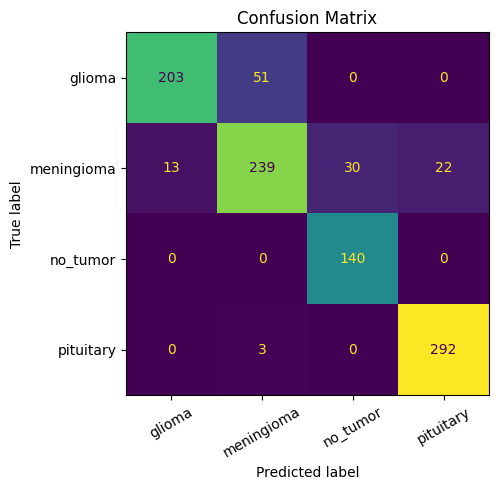

In [14]:
# Evaluate on test set
test_acc, preds, labels_ = eval_cls(cls_model, cls_test_dl)

print(f"\nTest Accuracy: {test_acc:.4f}\n")

# Classification report
print("Classification Report:\n")
print(classification_report(labels_, preds, target_names=CLASS_NAMES))

# Confusion matrix
cm = confusion_matrix(labels_, preds)

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES)
disp.plot(ax=ax, colorbar=False, xticks_rotation=30)

ax.set_title("Confusion Matrix")
plt.tight_layout()
plt.show()